In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
model = load_model("eye_state_cnn_20_20.keras")

In [3]:
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')

In [4]:
y_pred_probs = model.predict(X_test, batch_size=32)

# convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step


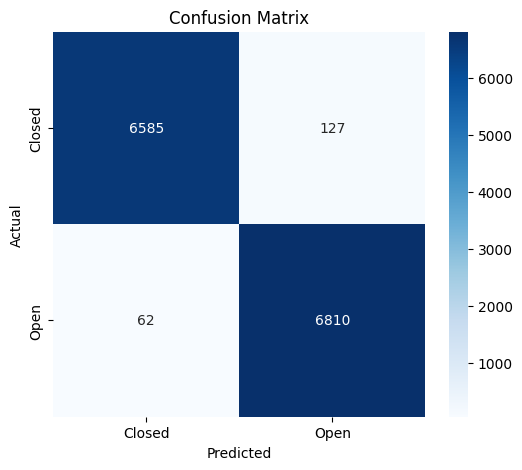

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Closed","Open"],
            yticklabels=["Closed","Open"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [6]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Closed Eyes","Open Eyes"]
)
print(report)

              precision    recall  f1-score   support

 Closed Eyes       0.99      0.98      0.99      6712
   Open Eyes       0.98      0.99      0.99      6872

    accuracy                           0.99     13584
   macro avg       0.99      0.99      0.99     13584
weighted avg       0.99      0.99      0.99     13584



425/425 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


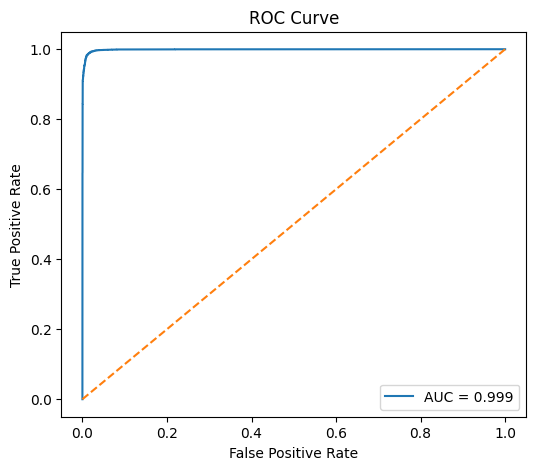

In [7]:
from sklearn.metrics import roc_curve, auc

# probabilities for positive class
y_scores = model.predict(X_test).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


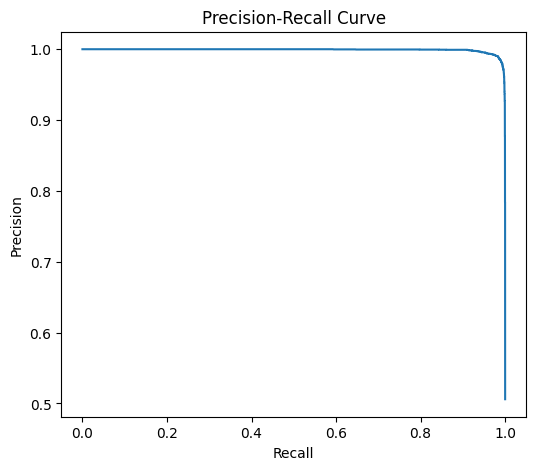

In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
